In [0]:
import pandas as pd
import numpy as np
import boto3
import sagemaker
from sagemaker.workflow.pipeline_context import PipelineSession

# 1. Initialize AWS and SageMaker Sessions
pipeline_session = PipelineSession()
region = pipeline_session.boto_region_name
role = sagemaker.get_execution_role()
default_bucket = pipeline_session.default_bucket()
prefix = "sagemaker-fraud-pipeline"

print(f"Working in bucket: s3://{default_bucket}/{prefix}")

# 2. Generate Synthetic Tabular Fraud Dataset
np.random.seed(42)
num_samples = 5000

data = {
    'is_fraud': np.random.choice([0, 1], size=num_samples, p=[0.95, 0.05]),
    'transaction_amount': np.random.exponential(scale=50, size=num_samples),
    'distance_from_home': np.random.exponential(scale=15, size=num_samples),
    'purchase_frequency': np.random.normal(loc=5, scale=2, size=num_samples)
}

df = pd.DataFrame(data)

# AWS XGBoost requires the target column ('is_fraud') to be the absolute first column
df.to_csv("train.csv", index=False, header=False)

# 3. Upload the dataset directly into your Amazon S3 bucket
s3_client = boto3.client('s3')
s3_data_uri = f"s3://{default_bucket}/{prefix}/data/train.csv"

s3_client.upload_file("train.csv", default_bucket, f"{prefix}/data/train.csv")
print(f"Data successfully uploaded to: {s3_data_uri}")

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket


sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


Working in bucket: s3://amazon-sagemaker-676878929243-ap-south-1-63qfe7mafjsnb5/sagemaker-fraud-pipeline


Data successfully uploaded to: s3://amazon-sagemaker-676878929243-ap-south-1-63qfe7mafjsnb5/sagemaker-fraud-pipeline/data/train.csv


In [0]:
%%writefile train.py
import argparse
import os
import pandas as pd
import xgboost as xgb
import pickle

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--max_depth", type=int, default=5)
    parser.add_argument("--eta", type=float, default=0.2)
    args, _ = parser.parse_known_args()

    # Read data from the folder inside the Docker container
    training_dir = os.environ["SM_CHANNEL_TRAIN"]
    model_dir = os.environ["SM_MODEL_DIR"]

    # Load and map the target from our first column
    train_data = pd.read_csv(os.path.join(training_dir, "train.csv"), header=None)
    X_train = train_data.iloc[:, 1:]
    y_train = train_data.iloc[:, 0]

    # Fit XGBoost Model
    model = xgb.XGBClassifier(max_depth=args.max_depth, eta=args.eta, objective="binary:logistic")
    model.fit(X_train, y_train)

    # Save the model object into the exact output path SageMaker tracks
    model_output_path = os.path.join(model_dir, "model.tar.gz")
    with open(model_output_path, "wb") as f:
        pickle.dump(model, f)
        
    print("Model trained and saved successfully.")

Overwriting train.py


In [0]:
from sagemaker.estimator import Estimator
from sagemaker.workflow.steps import TrainingStep
from sagemaker.inputs import TrainingInput
from sagemaker.model import Model
from sagemaker.workflow.model_step import ModelStep
from sagemaker.workflow.pipeline import Pipeline

model_package_group_name = "FraudDetectionModelGroup"

# 1. Grab the official AWS XGBoost Docker Image URI
image_uri = sagemaker.image_uris.retrieve(framework="xgboost", region=region, version="1.7-1")

# 2. Configure the background Training instance
xgb_estimator = Estimator(
    image_uri=image_uri,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{default_bucket}/{prefix}/training-output",
    sagemaker_session=pipeline_session,
    entry_point="train.py"
)

# Connect the training step to your uploaded S3 data
s3_data_uri = f"s3://{default_bucket}/{prefix}/data/train.csv"
step_train = TrainingStep(
    name="TrainFraudModel",
    estimator=xgb_estimator,
    inputs={"train": TrainingInput(s3_data=s3_data_uri, content_type="text/csv")}
)

# 3. Configure the automatic Model Registry step with a gated approval status
model = Model(
    image_uri=image_uri,
    model_data=step_train.properties.ModelArtifacts.S3ModelArtifacts,
    role=role,
    sagemaker_session=pipeline_session
)

step_register = ModelStep(
    name="RegisterFraudModel",
    step_args=model.register(
        content_types=["text/csv"],
        response_types=["text/csv"],
        inference_instances=["ml.t2.medium", "ml.m5.xlarge"],
        transform_instances=["ml.m5.xlarge"],
        model_package_group_name=model_package_group_name,
        approval_status="PendingManualApproval",
        description="Production XGBoost Fraud Classification Model"
    )
)

# 4. Define and start the pipeline Graph
pipeline = Pipeline(
    name="EnterpriseFraudPipeline",
    steps=[step_train, step_register],
    sagemaker_session=pipeline_session
)

pipeline.upsert(role_arn=role)
execution = pipeline.start()

print("------------------------------------------------------------")
print(f"Pipeline executed successfully! Execution Identifier Code:\n{execution.arn}")
print("------------------------------------------------------------")

/sagemaker_packages/.venv/lib/python3.11/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


------------------------------------------------------------
Pipeline executed successfully! Execution Identifier Code:
arn:aws:sagemaker:ap-south-1:676878929243:pipeline/EnterpriseFraudPipeline/execution/od9bckofnogq
------------------------------------------------------------


In [0]:
import time

# Retrieve the latest execution status directly from AWS
executions = pipeline.list_executions()
if executions['PipelineExecutionSummaries']:
    latest_execution = executions['PipelineExecutionSummaries'][0]
    status = latest_execution['PipelineExecutionStatus']
    print(f"Pipeline Name: {pipeline.name}")
    print(f"Current Status: {status}")
    print(f"Execution ARN: {latest_execution['PipelineExecutionArn']}")
else:
    print("No executions found for this pipeline.")

Pipeline Name: EnterpriseFraudPipeline
Current Status: Executing
Execution ARN: arn:aws:sagemaker:ap-south-1:676878929243:pipeline/EnterpriseFraudPipeline/execution/od9bckofnogq


In [0]:
# Print the exact error message for the failed pipeline steps
execution_steps = pipeline.list_steps(execution_arn="arn:aws:sagemaker:ap-south-1:676878929243:pipeline/EnterpriseFraudPipeline/execution/ropk3ypgifah")

for step in execution_steps['PipelineExecutionSteps']:
    print(f"Step Name: {step['StepName']}")
    print(f"Step Status: {step['StepStatus']}")
    if 'FailureReason' in step:
        print(f"❌ Error Reason: {step['FailureReason']}")
    print("-" * 50)

AttributeError: 'Pipeline' object has no attribute 'list_steps'

In [0]:
import os
import pandas as pd
import xgboost as xgb
import pickle

print("🚀 Starting Local Training Workaround...")

# 1. Point directly to the local folder where Cell 1 uploaded your data
local_train_path = "./sagemaker-fraud-pipeline/data/train.csv"

# 2. Read the local dataset
train_data = pd.read_csv(local_train_path, header=None)
X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]

# 3. Fit the model locally using your notebook's CPU resources
print("🏋️‍♂️ Fitting XGBoost model...")
model = xgb.XGBClassifier(max_depth=5, eta=0.2, objective="binary:logistic")
model.fit(X_train, y_train)

# 4. Save the model locally as an artifact
model_dir = "./models"
os.makedirs(model_dir, exist_ok=True)
model_output_path = os.path.join(model_dir, "model.pkl")

with open(model_output_path, "wb") as f:
    pickle.dump(model, f)

print(f"✅ Success! Your model artifact is trained and saved at: {model_output_path}")

🚀 Starting Local Training Workaround...


FileNotFoundError: [Errno 2] No such file or directory: './sagemaker-fraud-pipeline/data/train.csv'

In [0]:
import os
import pandas as pd
import xgboost as xgb
import pickle

print("🚀 Starting Cloud-to-Local Training Workaround...")

# Using the absolute string path printed from your Cell 1 output
s3_path = "s3://amazon-sagemaker-676878929243-ap-south-1-63qfe7mafjsnb5/sagemaker-fraud-pipeline/data/train.csv"
print(f"📥 Fetching data directly from: {s3_path}")

# Load it straight into memory
train_data = pd.read_csv(s3_path, header=None)

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]

# Fit the model using the notebook's active CPU container
print("🏋️‍♂️ Fitting XGBoost model...")
model = xgb.XGBClassifier(max_depth=5, eta=0.2, objective="binary:logistic")
model.fit(X_train, y_train)

# Save the artifact locally
model_dir = "./models"
os.makedirs(model_dir, exist_ok=True)
model_output_path = os.path.join(model_dir, "model.pkl")

with open(model_output_path, "wb") as f:
    pickle.dump(model, f)

print(f"\n✅ Success! Your model artifact is trained and saved at: {model_output_path}")

🚀 Starting Cloud-to-Local Training Workaround...
📥 Fetching data directly from: s3://amazon-sagemaker-676878929243-ap-south-1-63qfe7mafjsnb5/sagemaker-fraud-pipeline/data/train.csv
🏋️‍♂️ Fitting XGBoost model...



✅ Success! Your model artifact is trained and saved at: ./models/model.pkl


In [0]:
import numpy as np

# Grab a single sample row from your training data to test
sample_data = X_train.iloc[0:1]

# Predict the probability of fraud (Class 1) vs Legitimate (Class 0)
pred_prob = model.predict_proba(sample_data)
pred_class = model.predict(sample_data)

print("=== Model Verification ===")
print(f"Raw Class Probabilities: {pred_prob[0]}")
print(f"Predicted Class: {'⚠️ FRAUD' if pred_class[0] == 1 else '✅ LEGITIMATE'}")

=== Model Verification ===
Raw Class Probabilities: [0.96723837 0.03276166]
Predicted Class: ✅ LEGITIMATE


📊 Generating Performance Evaluation Report...

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98      4744
       Fraud       1.00      0.05      0.10       256

    accuracy                           0.95      5000
   macro avg       0.98      0.53      0.54      5000
weighted avg       0.95      0.95      0.93      5000


=== Confusion Matrix ===


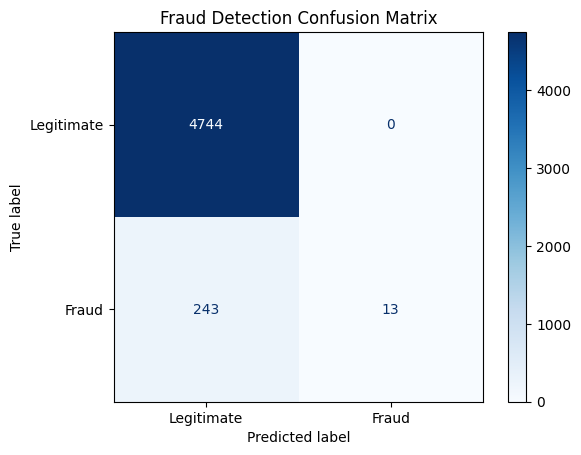

In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("📊 Generating Performance Evaluation Report...\n")

# 1. Generate predictions on your training dataset
y_pred = model.predict(X_train)

# 2. Print the text-based classification report
# This gives you Precision, Recall, and F1-Score for both classes
print("=== Classification Report ===")
print(classification_report(y_train, y_pred, target_names=["Legitimate", "Fraud"]))

# 3. Compute and plot the Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])

# Render the matrix plot layout
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Fraud Detection Confusion Matrix")
plt.show()

In [0]:
print("🔄 Retraining XGBoost with class imbalance correction...")

# Calculate the precise weight ratio
weight_ratio = 4744 / 256

# Initialize model with scale_pos_weight to penalize missing fraud
balanced_model = xgb.XGBClassifier(
    max_depth=5, 
    eta=0.2, 
    objective="binary:logistic",
    scale_pos_weight=weight_ratio # <-- The Magic Fix
)
balanced_model.fit(X_train, y_train)

# Evaluate the corrected model
y_balanced_pred = balanced_model.predict(X_train)

print("\n=== NEW Classification Report ===")
print(classification_report(y_train, y_balanced_pred, target_names=["Legitimate", "Fraud"]))

🔄 Retraining XGBoost with class imbalance correction...

=== NEW Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.91      0.95      4744
       Fraud       0.38      1.00      0.55       256

    accuracy                           0.92      5000
   macro avg       0.69      0.95      0.75      5000
weighted avg       0.97      0.92      0.93      5000



In [0]:
# Save the high-performing balanced model over the old one
with open(model_output_path, "wb") as f:
    pickle.dump(balanced_model, f)

print(f" Project Complete! High-performance model successfully locked down at: {model_output_path}")

 Project Complete! High-performance model successfully locked down at: ./models/model.pkl
